 ## Email Data Analysis
Email data analysis focuses on extracting actionable insights from email datasets by examining both communication patterns and content. This involves analyzing sending and receiving frequencies, identifying temporal trends across hours, days, and months, and understanding overall communication behavior.

The analysis also incorporates text-based techniques, including natural language processing (NLP), to extract meaningful information from email subject lines. By identifying frequently occurring keywords and recurring themes, the study highlights dominant patterns, particularly those related to job opportunities and recruitment activities.

In addition, visualization techniques are utilized to effectively represent trends and patterns within the data. These visual insights help uncover relationships, peak communication periods, and underlying structures, enabling a comprehensive understanding of how email communication evolves over time.

Overall, this analysis demonstrates how unstructured email data can be transformed into structured, interpretable insights that support data-driven decision-making and provide valuable perspectives on communication dynamics and job market trends.

## Import Libraries

- The required libraries are imported to facilitate data manipulation, analysis, visualization, and text processing. These tools enable efficient handling of structured datasets, support numerical computations, and provide capabilities for generating insightful visualizations and extracting meaningful information from textual data.

- Key libraries include those for data analysis (e.g., pandas), visualization (e.g., matplotlib, seaborn), and text processing (e.g., wordcloud and regular expressions).

In [1]:
import numpy as np
import pandas  as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.makedirs('../images', exist_ok=True)

## Converting Gmail Emails to CSV

- The dataset is initially available in `.mbox` format, which contains raw and unstructured email data. To enable efficient analysis, the data is transformed into a structured CSV format.

- This process involves parsing email records and extracting key attributes such as sender information, subject lines, timestamps, and other relevant metadata. Converting the data into a tabular structure improves accessibility, supports downstream processing, and allows seamless integration with data analysis and visualization workflows.

In [3]:
# Loading the mbox file

import mailbox
mbox = mailbox.mbox("..\\All mail Including Spam and Trash.mbox")
mbox

In [4]:
## Displaying the keys of the first email in the mbox to understand the structure of the data

keys2 = list(mbox[0].keys())

if 'From' in mbox[0]:
    print("Key 'From' found in the email keys.")
else:
    print("Key 'From' not found in the email keys.")

Key 'From' found in the email keys.


In [5]:
import csv

with open('../data/email_data.csv', 'w', newline='', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow(['From', 'To', 'Subject', 'Date', 'Thread', 'Labels'])
    for message in mbox:
        writer.writerow([message.get('From', ''),
                         message.get('To', ''),
                         message.get('Subject', ''),
                         message.get('Date', ''),
                         message.get('X-GM-THRID', ''),
                         message.get('X-Gmail-Labels', '')])

## Load Dataset
- The dataset is loaded from a CSV file into a structured DataFrame to facilitate analysis. This step ensures that the data is accessible in a tabular format, enabling efficient manipulation, inspection, and processing of email records.

- Once loaded, the dataset is examined to verify its structure, including columns, data types, and sample records, ensuring it is ready for subsequent data cleaning and analysis.

In [6]:
df = pd.read_csv('../data/email_data.csv')
df.head()

,From,To,Subject,Date,Thread,Labels
0,=?utf-8?q?Indro_Vicari_via_beBee?= <alert@noti...,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Programmatore_Fro...,"Mon, 13 Nov 2023 17:16:53 +0000",1782469952194646866,"Inbox,Category Updates,Unread"
1,"""Jason @ ML Mastery"" <jason@MachineLearningMas...",bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,"Mon, 13 Nov 2023 15:00:00 +0000 (UTC)",1782461343277158936,"Inbox,Category Updates,Unread"
2,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per SQL Developer a Rome,"Tue, 14 Nov 2023 12:33:11 +0100",1782538925643770298,"Inbox,Category Updates,Unread"
3,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per Junior Java Developer a ...,"Wed, 15 Nov 2023 12:33:24 +0100",1782629536219841707,"Inbox,Category Updates,Unread"
4,"""OpenCV.org"" <newsletter@opencv.org>",uzair shafique <bc090402541@gmail.com>,"Donate To Keep OpenCV Free To All, Impact Summ...","Wed, 15 Nov 2023 20:38:11 +0000 (UTC)",1782663811768277342,"Inbox,Category Updates,Unread"


## Data Cleaning
- Data cleaning is conducted to enhance the quality and integrity of the dataset by addressing inconsistencies, missing values, and noise present in raw email data. This step ensures that the dataset is reliable and suitable for meaningful analysis.

- Key cleaning operations include handling missing or null values, removing duplicate records, and preprocessing textual data by eliminating irrelevant characters, numbers, and common stopwords. Additionally, text normalization techniques are applied to standardize the data.

- By refining the dataset, this process reduces noise, improves data consistency, and lays a solid foundation for accurate exploratory analysis and feature engineering.

In [7]:
# Converting the 'Date' column to datetime format and handling any parsing errors
df["Date"] = df["Date"].apply(lambda x: pd.to_datetime(x, errors="coerce", utc=True))
df['Date'] = df['Date'].dt.tz_localize(None)
df

,From,To,Subject,Date,Thread,Labels
0,=?utf-8?q?Indro_Vicari_via_beBee?= <alert@noti...,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Programmatore_Fro...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread"
1,"""Jason @ ML Mastery"" <jason@MachineLearningMas...",bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread"
2,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread"
3,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread"
4,"""OpenCV.org"" <newsletter@opencv.org>",uzair shafique <bc090402541@gmail.com>,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread"
...,...,...,...,...,...,...
14729,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per SQL Developer in Rome,2023-10-19 09:41:05,1780176352685898505,"Inbox,Category Updates,Unread"
14730,foodpanda <contact@info.foodpanda.pk>,bc090402541@gmail.com,Khaas deals you wouldn't wanna miss =?UTF-8?B?...,2023-08-13 12:19:49,1774119953401055792,"Inbox,Category Updates,Unread"
14731,=?utf-8?q?Lorenzo__Mancini_via_beBee?= <alert@...,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Database_/_SQL_De...,2023-07-21 10:09:09,1772024390878438311,"Inbox,Category Updates,Unread"
14732,=?utf-8?B?bGF2b3JvIHRyYWJham8ub3Jn?= <info@tra...,"""bc090402541@gmail.com"" <bc090402541@gmail.com>",Offerte di lavoro per Web Developer in Salerno,2023-08-06 09:56:44,1773473160922129739,"Inbox,Category Updates,Unread"


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14734 entries, 0 to 14733
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   From     14734 non-null  str           
 1   To       14721 non-null  str           
 2   Subject  14687 non-null  str           
 3   Date     14734 non-null  datetime64[us]
 4   Thread   14734 non-null  int64         
 5   Labels   14734 non-null  str           
dtypes: datetime64[us](1), int64(1), str(4)
memory usage: 690.8 KB


In [9]:
import re

# Function to extract email addresses from a string
def extract_email(email_str):
    if pd.isna(email_str):
        return None
    match = re.findall(r'[\w\.-]+@[\w\.-]+', email_str)
    return match[0] if match else None

df['From'] = df['From'].apply(extract_email)
df['To'] = df['To'].apply(extract_email)
df.head()

,From,To,Subject,Date,Thread,Labels
0,alert@notification.bebee.com,bc090402541@gmail.com,=?utf-8?q?Nuova_posizione_di_Programmatore_Fro...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread"
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread"
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread"
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread"
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread"


In [10]:

from email.header import decode_header

# Function to decode email subjects that may be encoded in various formats
def clean_subject(subject):
    if pd.isna(subject):
        return None

    decoded_parts = decode_header(subject)
    cleaned_subject = ''
    for part, encoding in decoded_parts:
        if isinstance(part, bytes):
            cleaned_subject += part.decode(encoding or 'utf-8', errors='ignore')
        else:
            cleaned_subject += part
    return cleaned_subject


In [11]:
# Function to further clean the subject by removing common prefixes and extra whitespace
def clean_text(text):
    if pd.isna(text):
        return None

    text = re.sub(r'^(Re:|Fwd:)\s*', '', text, flags=re.IGNORECASE)
    text = text.replace('_',' ')
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df['Subject'] = df['Subject'].apply(clean_subject)
df['Subject'] = df['Subject'].apply(clean_text)
df


,From,To,Subject,Date,Thread,Labels
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread"
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread"
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread"
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread"
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread"
...,...,...,...,...,...,...
14729,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer in Rome,2023-10-19 09:41:05,1780176352685898505,"Inbox,Category Updates,Unread"
14730,contact@info.foodpanda.pk,bc090402541@gmail.com,Khaas deals you wouldn't wanna miss 👉🏻,2023-08-13 12:19:49,1774119953401055792,"Inbox,Category Updates,Unread"
14731,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Database / SQL Developer in...,2023-07-21 10:09:09,1772024390878438311,"Inbox,Category Updates,Unread"
14732,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Web Developer in Salerno,2023-08-06 09:56:44,1773473160922129739,"Inbox,Category Updates,Unread"


## Feature Engineering
- Feature engineering is conducted to transform raw and unstructured email data into structured features that facilitate meaningful analysis. This includes extracting temporal attributes such as hour, day of the week, and month, as well as processing textual data from email subjects to derive informative patterns.

- These engineered features play a critical role in enabling downstream analysis, including trend identification, visualization, and text-based insights. By systematically refining the dataset, this step improves data quality, enhances interpretability, and lays the foundation for more advanced analytical or machine learning tasks.

In [12]:

# Labeling emails as 'Sent' or 'Received' based on the 'From' field

my_email = "bc09402541@gmail.com"
def label_email(row):
    if row['From'] == my_email:
        return 'Sent'
    else:
        return 'Received'

df['Email_Type'] = df.apply(label_email, axis=1)
df.head()


,From,To,Subject,Date,Thread,Labels,Email_Type
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,1782469952194646866,"Inbox,Category Updates,Unread",Received
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,1782461343277158936,"Inbox,Category Updates,Unread",Received
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,1782538925643770298,"Inbox,Category Updates,Unread",Received
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,1782629536219841707,"Inbox,Category Updates,Unread",Received
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,1782663811768277342,"Inbox,Category Updates,Unread",Received


In [13]:
# Extracting the main label from the 'Labels' column to categorize emails into broader categories
def extract_main_label(label):
    if pd.isna(label):
        return "Unknown"

    if "Promotions" in label:
        return "Promotions"
    elif "Social" in label:
        return "Social"
    elif "Updates" in label:
        return "Updates"
    elif "Personal" in label:
        return "Personal"
    elif "Important" in label:
        return "Important"
    else:
        return "Other"

df['Main_Label'] = df['Labels'].apply(extract_main_label)
df[df['Main_Label'].str.contains("Important")].head()

,From,To,Subject,Date,Thread,Labels,Email_Type,Main_Label
2076,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2023-07-10 07:55:38,1771019403880573430,"Sent,Inbox,Important,Opened",Received,Important
2387,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2023-07-10 12:15:09,1771035738767687040,"Sent,Inbox,Important,Opened",Received,Important
6556,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2022-12-27 02:27:52,1753332269670557175,"Sent,Inbox,Important,Opened",Received,Important
7043,bc090402541@gmail.com,bc090402541@gmail.com,I am sharing 'Uzair Shafique (1)' with you,2022-11-03 17:28:33,1748496794610763834,"Sent,Inbox,Important,Opened",Received,Important
8389,bc090402541@gmail.com,bc090402541@gmail.com,NaN,2022-10-13 17:24:21,1746594012769979922,"Sent,Inbox,Important,Opened",Received,Important


In [14]:
# Dropping the 'Labels' and 'Thread' columns as they are no longer needed for analysis
df.drop(columns=['Labels', 'Thread'], inplace=True)

In [15]:
df.head(10)

,From,To,Subject,Date,Email_Type,Main_Label
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,Received,Updates
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,Received,Updates
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,Received,Updates
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,Received,Updates
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,Received,Updates
5,monster@notifications.monster.com,bc090402541@gmail.com,🛎️ Il tuo avviso di lavoro per: Sistemista inf...,2023-11-19 15:02:39,Received,Updates
6,dsml.mit@learn.mygreatlearning.com,bc090402541@gmail.com,[Session Reminder] Predicting Holiday Travel F...,2023-11-13 10:17:16,Received,Updates
7,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Front End Web Developer ...,2023-11-10 10:12:44,Received,Updates
8,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer in...,2023-11-18 11:33:23,Received,Updates
9,mailrobot@mail.xing.com,bc090402541@gmail.com,Radikal Arbeiten: Warum wir eine neue Arbeitsp...,2023-11-09 07:15:01,Received,Promotions


In [16]:
df['domains'] = df['From'].str.extract(r'@([^>]+)')

In [17]:
# Extracting additional features from the 'Date' column to analyze email communication patterns based on time
df['weekday'] = df['Date'].dt.day_name()
df['month'] = df['Date'].dt.month_name()
df['months_num'] = df['Date'].dt.month
df['hours']= df['Date'].dt.hour


In [18]:
df.head()

,From,To,Subject,Date,Email_Type,Main_Label,domains,weekday,month,months_num,hours
0,alert@notification.bebee.com,bc090402541@gmail.com,Nuova posizione di Programmatore Front End in ...,2023-11-13 17:16:53,Received,Updates,notification.bebee.com,Monday,November,11,17
1,jason@MachineLearningMastery.com,bc090402541@gmail.com,Looking To Stay Current in Data Analytics?,2023-11-13 15:00:00,Received,Updates,MachineLearningMastery.com,Monday,November,11,15
2,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per SQL Developer a Rome,2023-11-14 11:33:11,Received,Updates,trabajo.org,Tuesday,November,11,11
3,info@trabajo.org,bc090402541@gmail.com,Offerte di lavoro per Junior Java Developer a ...,2023-11-15 11:33:24,Received,Updates,trabajo.org,Wednesday,November,11,11
4,newsletter@opencv.org,bc090402541@gmail.com,"Donate To Keep OpenCV Free To All, Impact Summ...",2023-11-15 20:38:11,Received,Updates,opencv.org,Wednesday,November,11,20


## Exploratory Data Analysis

- Exploratory Data Analysis (EDA) is conducted to gain a comprehensive understanding of the email dataset, including its temporal patterns, structural characteristics, and underlying themes. The primary objective is to identify trends in communication behavior and extract actionable insights from both metadata and email subject content.

- The analysis examines email activity across multiple time dimensions, such as hourly, daily, and monthly distributions, while also leveraging text-based techniques to uncover recurring patterns related to job opportunities and recruitment activity.

- By combining statistical summaries with visual exploration, this section provides a data-driven foundation for identifying communication dynamics and potential job market trends embedded within the dataset.

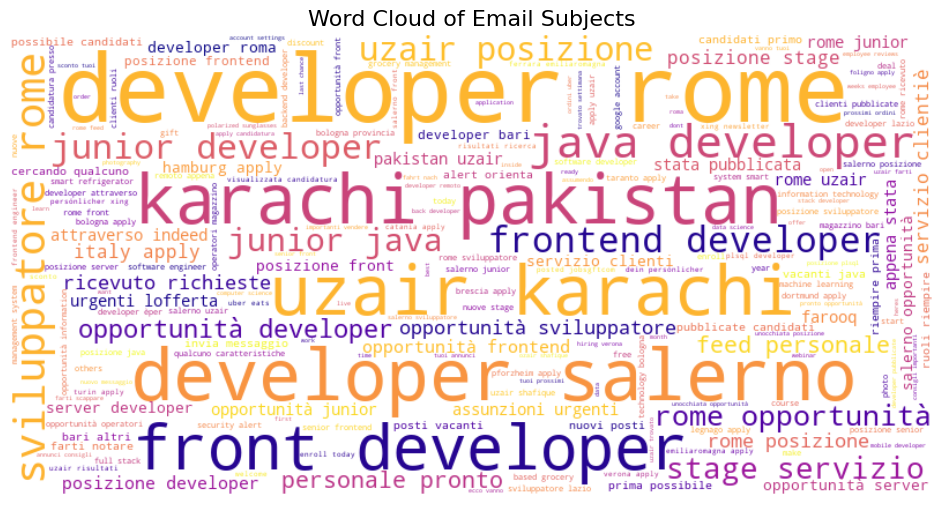

In [19]:

# Creating a word cloud of email subjects to visualize the most common words used in email subjects while excluding common stopwords and custom stopwords relevant to the context of email communication
from wordcloud import WordCloud
from wordcloud import STOPWORDS

stopwords = set(STOPWORDS)
custom_stopwords = {'per','con','il','la','di','dalla','della','hai','sono',
                    'tua','tuo','e','è','che','a','in','le','te','not', 'lavoro', 'offerte',
                      'jobs','come', 'questa', 'nuova', 'oggi', 'lavoro'
    }
stopwords.update(custom_stopwords)

text = " ".join(df['Subject'].dropna())
text = text.lower()
text = re.sub(r'\d+', '', text)
text = re.sub(r'[^\w\s]', '', text)

words = re.findall(r'\b\w{4,}\b', text)
words = [word for word in words if word not in stopwords]
text = " ".join(words)


wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='plasma',
    stopwords=stopwords
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Email Subjects", fontsize=16)
plt.savefig('../images/email_subject_wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()


## Analysis of Email Subject
- The word cloud reveals that a substantial portion of emails is centered around job opportunities, particularly in web and software development roles such as frontend and Java development.

- The consistent presence of hiring-related terms suggests that the dataset is predominantly recruitment-focused, reflecting strong demand within the technology sector.


## Top Email Senders / Domains

In [20]:
top_senders = df['domains'].value_counts().head(10).reset_index()
top_senders.columns = ['domain', 'count']
top_senders

,domain,count
0,trabajo.org,1845
1,notification.bebee.com,1737
2,glassdoor.com,1074
3,mustakbil.com,845
4,m.photoserge.com,716
5,wish.com,566
6,talent.com,456
7,info.foodpanda.pk,390
8,indeed.com,367
9,jobsora.com,328


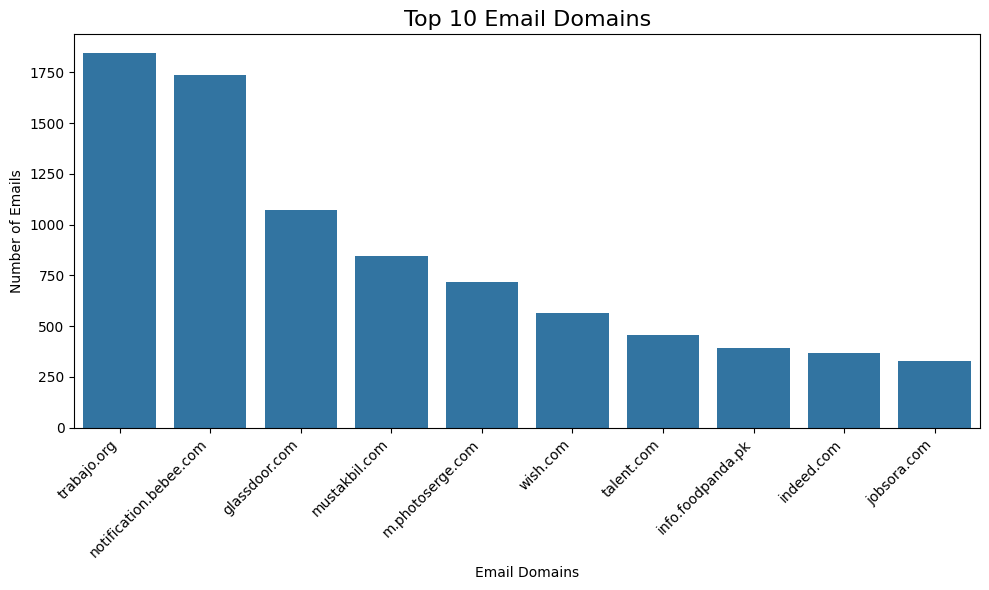

In [21]:

plt.figure(figsize=(10, 6))
sns.barplot(data=top_senders, x='domain', y='count')
plt.title("Top 10 Email Domains", fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Emails")
plt.xlabel("Email Domains")
plt.tight_layout()
plt.savefig('../images/top_email_domains.png',dpi=300, bbox_inches='tight')
plt.show()


## Analysis Of Top Email Sender/Domains
- The analysis reveals that a small number of domains dominate overall email traffic, with sources such as trabajo.org and bebee.com contributing the highest volume of messages. 

- This concentration indicates that the majority of communication originates from a limited set of platforms, most likely job portals or automated notification systems, reflecting a centralized pattern of email generation.

## Email Activity Heatmap (Weekday vs Hour)

In [22]:
heatmap = df.pivot_table(index='weekday', columns='hours', aggfunc='size',fill_value=0)
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap = heatmap.reindex(order)


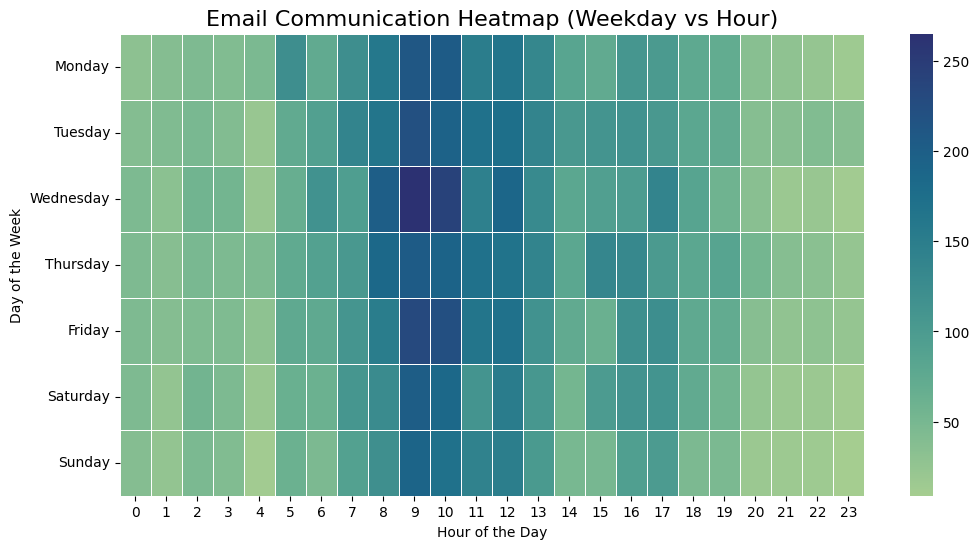

In [23]:
# Plotting heatmap of email communication by weekday and hour to visualize patterns in email communication across different times of the day and days of the week
plt.figure(figsize=(12, 6))
ax =sns.heatmap(heatmap, cmap='crest', linewidths=.6)
plt.title("Email Communication Heatmap (Weekday vs Hour)", fontsize=16)
plt.xlabel("Hour of the Day")
plt.ylabel ("Day of the Week")
plt.savefig('../images/email_heatmap.png',dpi=300, bbox_inches='tight')
plt.show()


## Analysis of Email Acitivty (Weekdays vs Hours)
- Email activity peaks during weekday mornings, particularly between 9 AM and 11 AM, with Wednesday exhibiting the highest level of activity. 

- In contrast, activity declines significantly during late evenings and weekends, indicating that communication is largely aligned with standard business hours.

## Email Activity by Day of the Week

In [24]:
# Count emails by weekday to identify patterns in email communication across different days of the week
weekdays_count = df['weekday'].value_counts().reset_index()
weekdays_count.columns = ['weekday', 'count']
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

C:\Users\user\AppData\Local\Temp\ipykernel_1324\157730500.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekdays_count, x='weekday', y='count', order=order, palette='crest')


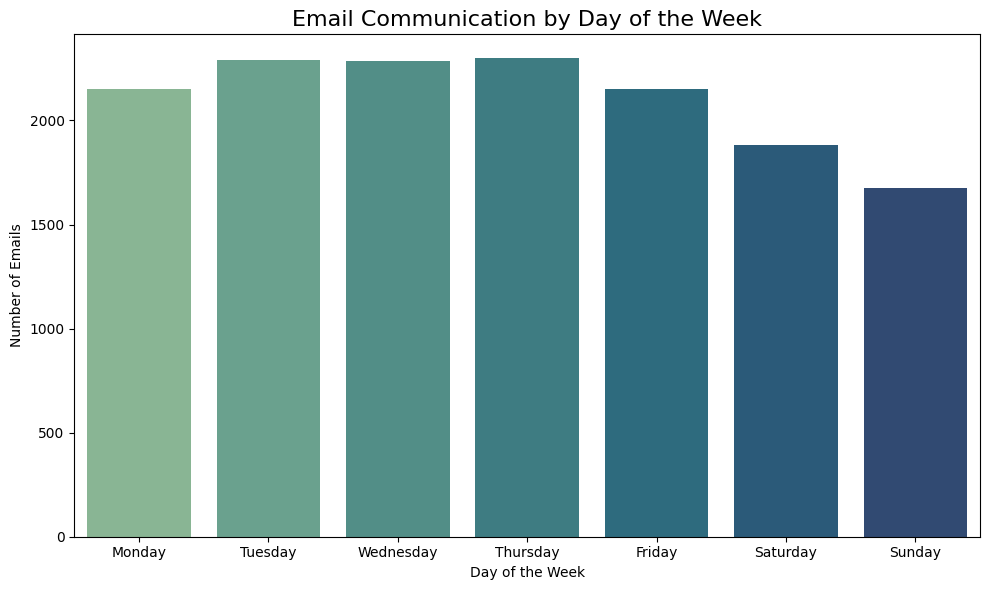

In [25]:

# Plotting the number of emails received/sent on each day of the week to identify patterns in email communication
plt.figure(figsize=(10, 6))
sns.barplot(data=weekdays_count, x='weekday', y='count', order=order, palette='crest')
plt.title("Email Communication by Day of the Week", fontsize=16)
plt.xlabel("Day of the Week")
plt.ylabel("Number of Emails")
plt.tight_layout()
plt.savefig('../images/email_weekday_count.png',dpi=300, bbox_inches='tight')
plt.show()


## Analysis of Emails Acitvity by Day of Week
- Email activity is highest during weekdays, particularly from Tuesday to Thursday, while weekends show a noticeable decline. 

- This pattern indicates that the majority of communication is work-related and aligns with typical business communication practices

## Monthly Email Trends


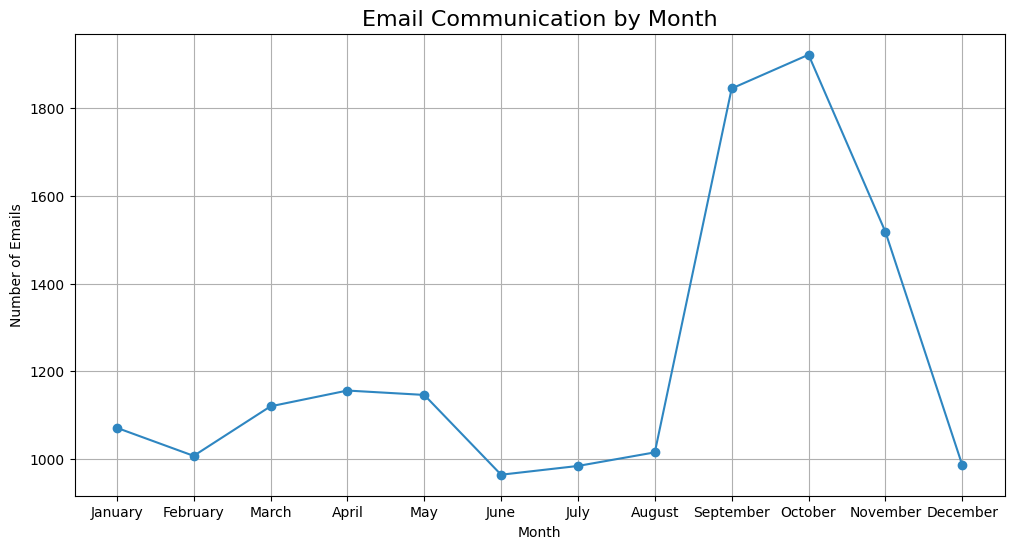

In [26]:
# Analyzing email communication patterns by month to identify trends in email activity throughout the year
months_count = df.groupby(['month', 'months_num']).size().reset_index(name='total_size')
months_count = months_count.sort_values('months_num')

plt.figure(figsize=(12, 6))
plt.plot(months_count['month'], months_count['total_size'], marker='o', linestyle='-', color='#2E86C1')
plt.title("Email Communication by Month", fontsize=16)
plt.xlabel("Month")
plt.grid(True)
plt.ylabel("Number of Emails")
plt.savefig('../images/email_monthly_trends.png',dpi=300, bbox_inches='tight')
plt.show()

## Analysis of Monthly Email Trends
- Email activity remains relatively stable during the first half of the year, followed by a noticeable increase in September and October, indicating peak communication periods. 

- This pattern suggests the presence of seasonal or business-driven fluctuations in email activity.

## Conclusions

After analyzing the email dataset, several clear patterns emerge regarding communication behavior and content.
- Email activity is significantly higher during weekdays, particularly in the middle of the week, while weekends show minimal activity. This indicates that the majority of communication is work-related rather than personal.

- In terms of timing, emails are concentrated during standard working hours, especially in the morning. This aligns with typical professional workflows, where communication is prioritized early in the day.

- Monthly trends reveal that email activity is not evenly distributed throughout the year. Noticeable increases in certain months suggest possible links to hiring cycles, business activity peaks, or seasonal demand.

- Content analysis shows that a large portion of emails is related to job opportunities, particularly in software development roles. Frequent terms such as developer, frontend, and Java indicate strong demand in the tech sector, especially for development-related positions.

## Business Implications
- Email data can be used to identify hiring trends and job market demand
- Communication patterns can help optimize email filtering and prioritization systems
- Peak activity periods can inform automation systems and alert scheduling
- Job-related email trends can support career planning and market analysis

Overall, this analysis demonstrates how unstructured email data can be transformed into actionable insights about communication behavior and job market trends.